# 🔐 Global Data Breaches Analysis — HaveIBeenPwned
## Notebook 03 — Analyse Exploratoire (EDA)

**Source** : `../data/breaches_clean.csv` + `../data/breaches_exploded.csv`  
**Auteur** : Esmel Amari (Phil)  
**Objectif** : Explorer les données nettoyées pour répondre aux grandes questions analytiques du projet.

---

### ❓ Questions analytiques couvertes
1. Quelle est l'évolution du nombre de fuites par année ?
2. Quelles années ont eu le plus de comptes compromis ?
3. Quels secteurs sont les plus touchés ?
4. Quels types de données sont les plus exposés ?
5. Quelle est la distribution des tailles de fuites ?
6. Quelles sont les 10 fuites les plus graves ?
7. Quelle est la part des fuites vérifiées vs non vérifiées ?
8. Y a-t-il une corrélation entre la taille et le score de gravité ?

---

## 📚 1. Import des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

# ── Style global ──────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='Blues_r')
plt.rcParams.update({
    'figure.dpi'      : 130,
    'font.family'     : 'DejaVu Sans',
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
})

PALETTE  = '#1a3a5c'   # bleu foncé principal
PALETTE2 = '#e74c3c'   # rouge accent
PALETTE3 = '#2980b9'   # bleu clair

print('✅ Librairies importées avec succès')
print(f'📅 Date : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

✅ Librairies importées avec succès
📅 Date : 2026-04-18 05:36:31


## 📂 2. Chargement des données

In [2]:
df       = pd.read_csv('../data/breaches_clean.csv', parse_dates=['BreachDate', 'AddedDate'])
df_expl  = pd.read_csv('../data/breaches_exploded.csv', parse_dates=['BreachDate'])

print(f'📊 Dataset principal  : {df.shape[0]} fuites x {df.shape[1]} colonnes')
print(f'📊 Dataset explosé    : {df_expl.shape[0]} lignes x {df_expl.shape[1]} colonnes')
print(f'📅 Période couverte   : {df["BreachDate"].min().year} → {df["BreachDate"].max().year}')

📊 Dataset principal  : 974 fuites x 27 colonnes
📊 Dataset explosé    : 5105 lignes x 27 colonnes
📅 Période couverte   : 2007 → 2026


## 📊 3. Statistiques descriptives globales

In [3]:
total_breaches  = len(df)
total_accounts  = df['PwnCount'].sum()
verified_pct    = df['IsVerified'].mean() * 100
sensitive_pct   = df['IsSensitive'].mean() * 100
avg_size        = df['PwnCount'].median()
biggest_breach  = df.loc[df['PwnCount'].idxmax(), 'Name']
biggest_count   = df['PwnCount'].max()

print('=' * 55)
print('         📌 KPIs GLOBAUX DU DATASET')
print('=' * 55)
print(f'  Nombre total de fuites         : {total_breaches:>8,}')
print(f'  Total comptes compromis        : {total_accounts:>8,.0f}')
print(f'  En milliards                   : {total_accounts/1e9:>8.2f}B')
print(f'  Fuites vérifiées               : {verified_pct:>7.1f}%')
print(f'  Fuites sensibles               : {sensitive_pct:>7.1f}%')
print(f'  Taille médiane (comptes)       : {avg_size:>8,.0f}')
print(f'  Plus grande fuite              : {biggest_breach} ({biggest_count/1e6:.0f}M comptes)')
print('=' * 55)

         📌 KPIs GLOBAUX DU DATASET
  Nombre total de fuites         :      974
  Total comptes compromis        : 17,523,788,830
  En milliards                   :    17.52B
  Fuites vérifiées               :    95.7%
  Fuites sensibles               :     9.3%
  Taille médiane (comptes)       : 1,024,967
  Plus grande fuite              : SynthientCredentialStuffingThreatData (1957M comptes)


---
## 📈 4. Tendances temporelles
### Q1 — Évolution du nombre de fuites par année

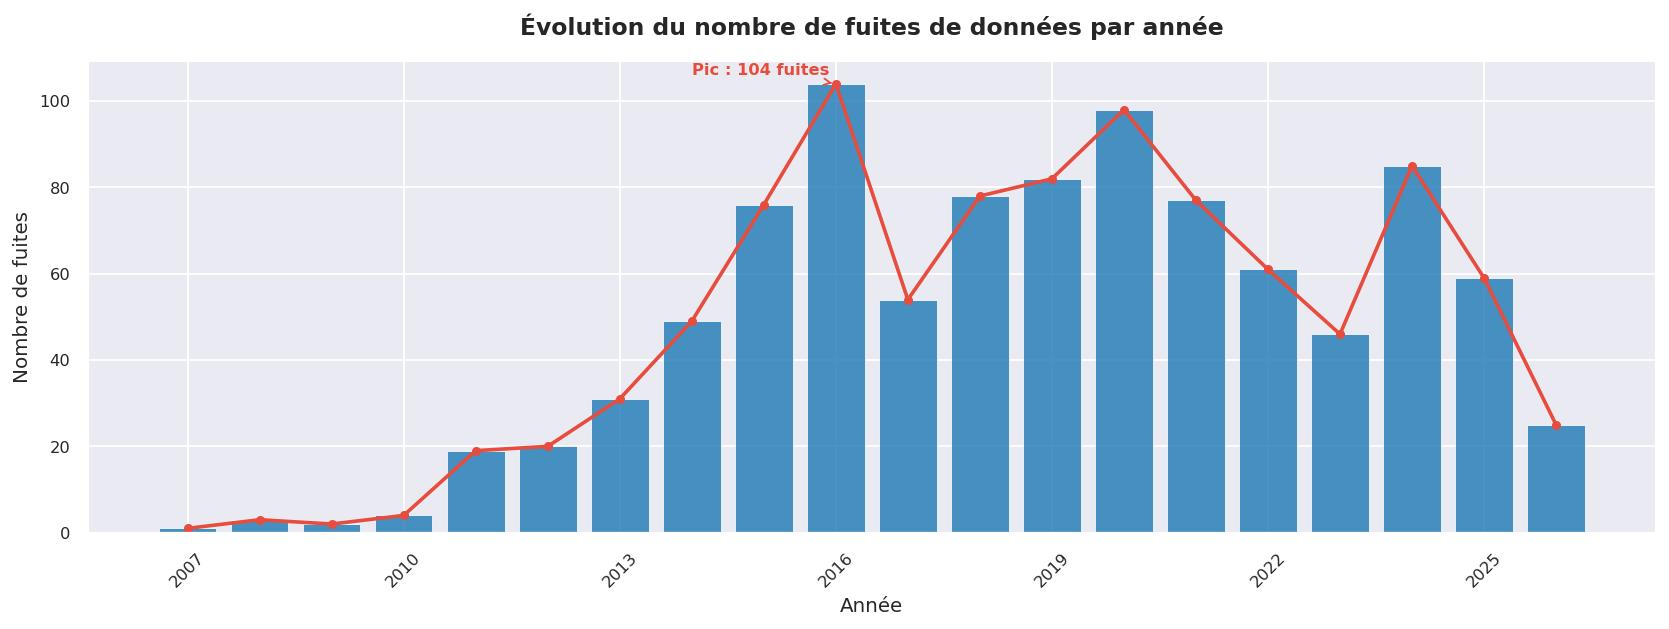

✅ Graphique sauvegardé : 01_fuites_par_annee.png


In [4]:
fuites_par_an = df.groupby('Year').size().reset_index(name='NbFuites')
fuites_par_an = fuites_par_an[fuites_par_an['Year'] >= 2007]

fig, ax = plt.subplots(figsize=(13, 5))

bars = ax.bar(fuites_par_an['Year'], fuites_par_an['NbFuites'],
              color=PALETTE3, edgecolor='white', linewidth=0.5, alpha=0.85)

# Courbe de tendance
ax.plot(fuites_par_an['Year'], fuites_par_an['NbFuites'],
        color=PALETTE2, linewidth=2, marker='o', markersize=4, label='Tendance')

# Annoter la valeur maximale
max_row = fuites_par_an.loc[fuites_par_an['NbFuites'].idxmax()]
ax.annotate(f"Pic : {int(max_row['NbFuites'])} fuites",
            xy=(max_row['Year'], max_row['NbFuites']),
            xytext=(max_row['Year'] - 2, max_row['NbFuites'] + 2),
            arrowprops=dict(arrowstyle='->', color=PALETTE2),
            fontsize=9, color=PALETTE2, fontweight='bold')

ax.set_title('Évolution du nombre de fuites de données par année', pad=15)
ax.set_xlabel('Année')
ax.set_ylabel('Nombre de fuites')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/01_fuites_par_annee.png', bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 01_fuites_par_annee.png')

### Q2 — Comptes compromis par année (en millions)

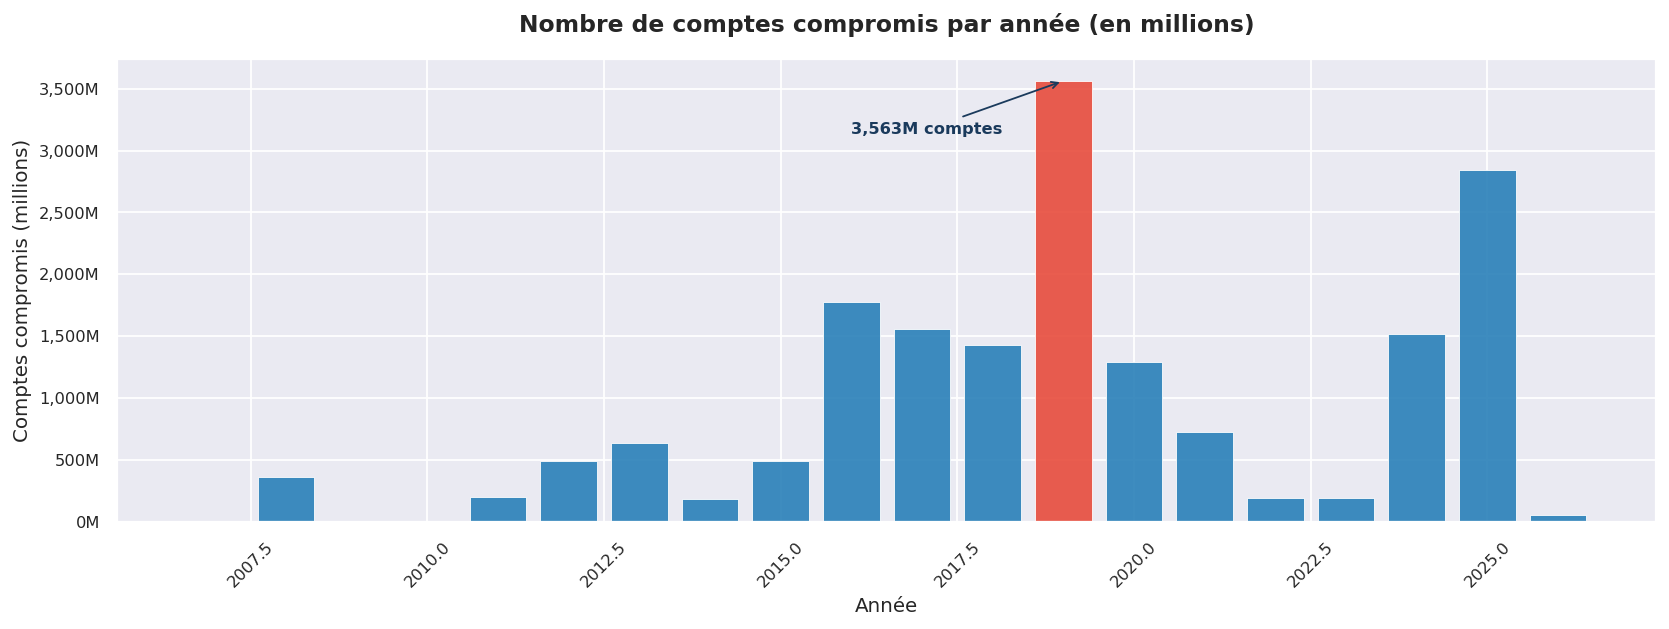

✅ Graphique sauvegardé : 02_comptes_par_annee.png


In [5]:
comptes_par_an = df.groupby('Year')['PwnCount'].sum().reset_index()
comptes_par_an['PwnCount_M'] = comptes_par_an['PwnCount'] / 1_000_000
comptes_par_an = comptes_par_an[comptes_par_an['Year'] >= 2007]

fig, ax = plt.subplots(figsize=(13, 5))

colors = [PALETTE2 if v == comptes_par_an['PwnCount_M'].max() else PALETTE3
          for v in comptes_par_an['PwnCount_M']]

ax.bar(comptes_par_an['Year'], comptes_par_an['PwnCount_M'],
       color=colors, edgecolor='white', linewidth=0.5, alpha=0.9)

# Annoter le pic
max_row = comptes_par_an.loc[comptes_par_an['PwnCount_M'].idxmax()]
ax.annotate(f"{max_row['PwnCount_M']:,.0f}M comptes",
            xy=(max_row['Year'], max_row['PwnCount_M']),
            xytext=(max_row['Year'] - 3, max_row['PwnCount_M'] * 0.88),
            arrowprops=dict(arrowstyle='->', color=PALETTE),
            fontsize=9, color=PALETTE, fontweight='bold')

ax.set_title('Nombre de comptes compromis par année (en millions)', pad=15)
ax.set_xlabel('Année')
ax.set_ylabel('Comptes compromis (millions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/02_comptes_par_annee.png', bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 02_comptes_par_annee.png')

---
## 🏭 5. Analyse par secteur
### Q3 — Secteurs les plus touchés

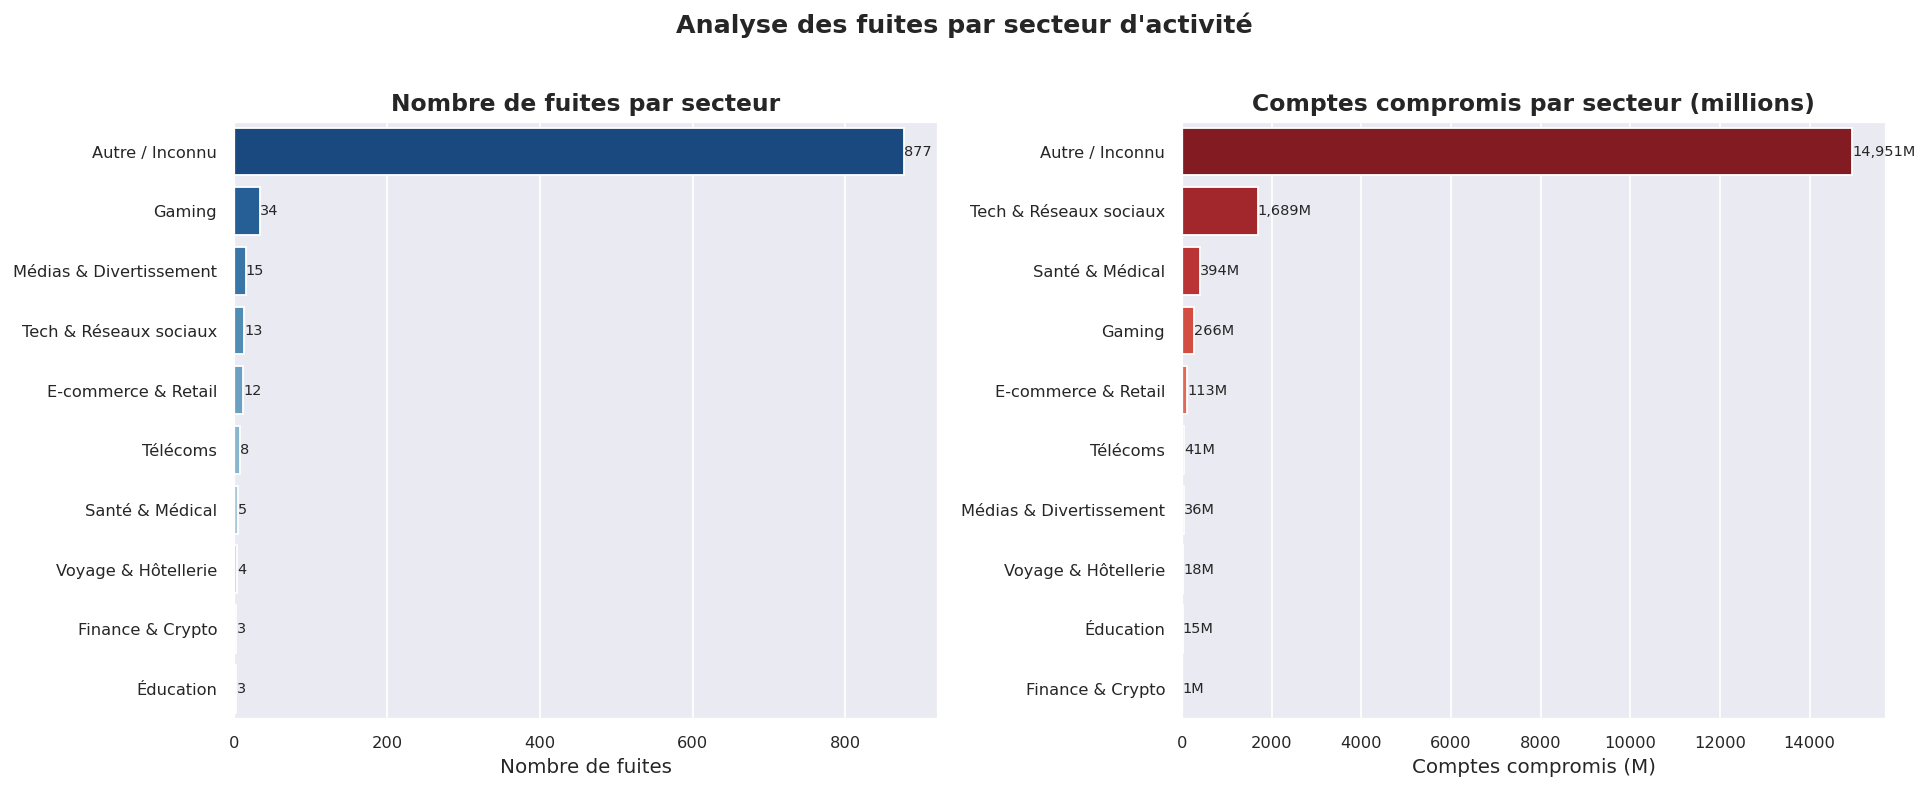

✅ Graphique sauvegardé : 03_fuites_par_secteur.png


In [6]:
sector_counts  = df['Sector'].value_counts().reset_index()
sector_counts.columns = ['Sector', 'NbFuites']

sector_pwn = df.groupby('Sector')['PwnCount'].sum().reset_index()
sector_pwn['PwnCount_M'] = sector_pwn['PwnCount'] / 1_000_000
sector_pwn = sector_pwn.sort_values('PwnCount_M', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Graphique gauche : nombre de fuites
sns.barplot(data=sector_counts, y='Sector', x='NbFuites',
            palette='Blues_r', ax=axes[0])
axes[0].set_title('Nombre de fuites par secteur')
axes[0].set_xlabel('Nombre de fuites')
axes[0].set_ylabel('')
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width())}', va='center', fontsize=8)

# Graphique droite : comptes compromis
sns.barplot(data=sector_pwn, y='Sector', x='PwnCount_M',
            palette='Reds_r', ax=axes[1])
axes[1].set_title('Comptes compromis par secteur (millions)')
axes[1].set_xlabel('Comptes compromis (M)')
axes[1].set_ylabel('')
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():,.0f}M', va='center', fontsize=8)

plt.suptitle('Analyse des fuites par secteur d\'activité', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../visuals/03_fuites_par_secteur.png', bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 03_fuites_par_secteur.png')

---
## 🗂️ 6. Analyse des types de données exposées
### Q4 — Types de données les plus fréquents

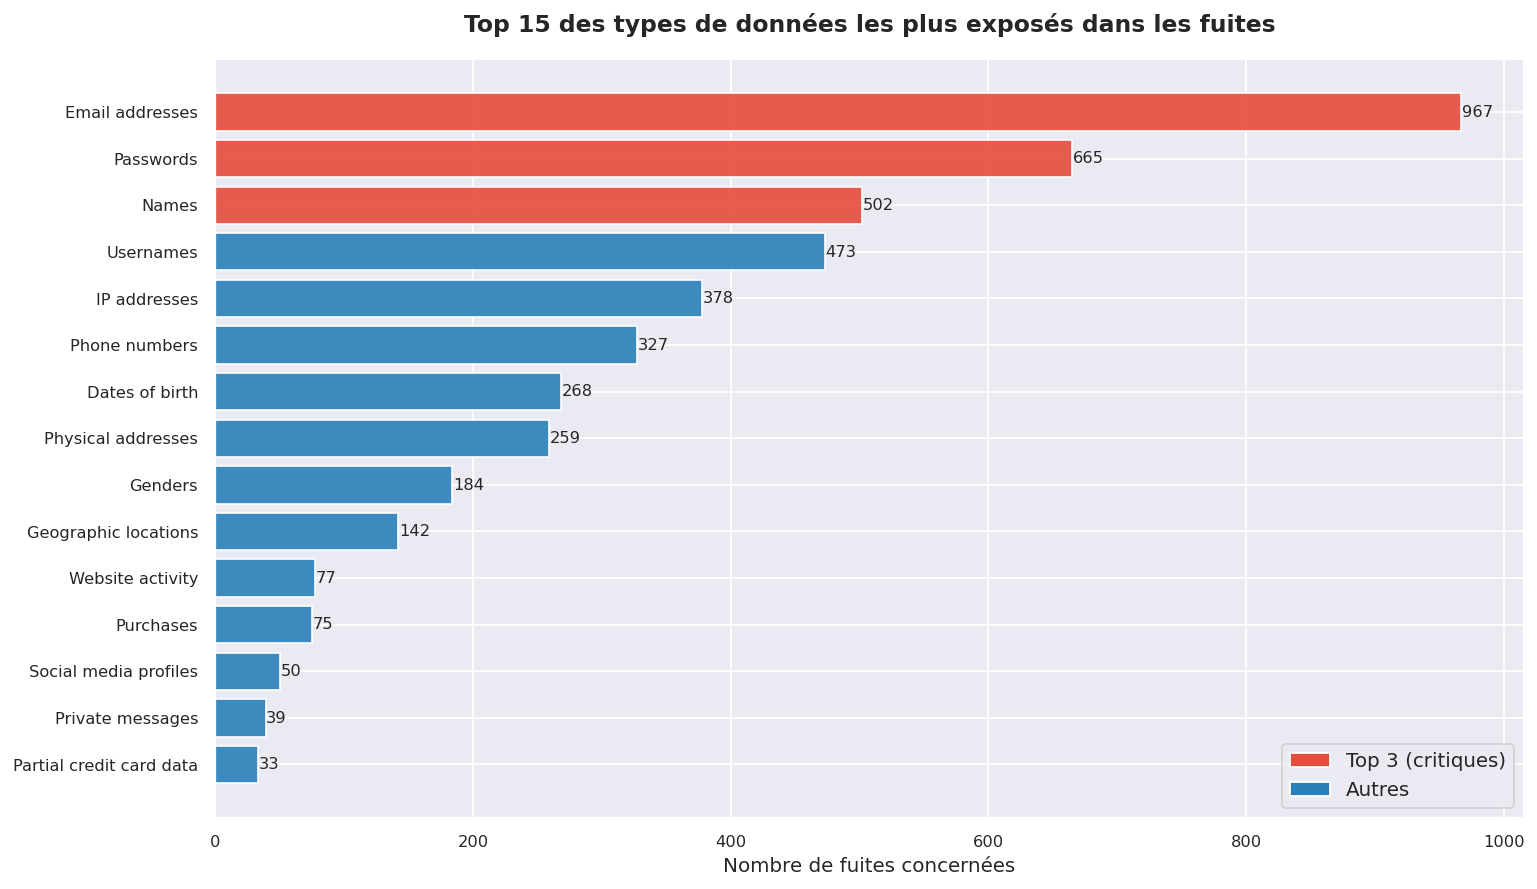

✅ Graphique sauvegardé : 04_types_donnees_exposes.png


In [7]:
top_dataclasses = df_expl['DataClass'].value_counts().head(15).reset_index()
top_dataclasses.columns = ['DataClass', 'Frequence']

fig, ax = plt.subplots(figsize=(12, 7))

colors = [PALETTE2 if i < 3 else PALETTE3 for i in range(len(top_dataclasses))]
bars = ax.barh(top_dataclasses['DataClass'][::-1],
               top_dataclasses['Frequence'][::-1],
               color=colors[::-1], edgecolor='white', alpha=0.9)

for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=9)

ax.set_title('Top 15 des types de données les plus exposés dans les fuites', pad=15)
ax.set_xlabel('Nombre de fuites concernées')
ax.set_ylabel('')

# Légende
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PALETTE2, label='Top 3 (critiques)'),
                   Patch(facecolor=PALETTE3, label='Autres')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../visuals/04_types_donnees_exposes.png', bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 04_types_donnees_exposes.png')

---
## 📏 7. Distribution des tailles de fuites
### Q5 — Répartition par catégorie de taille

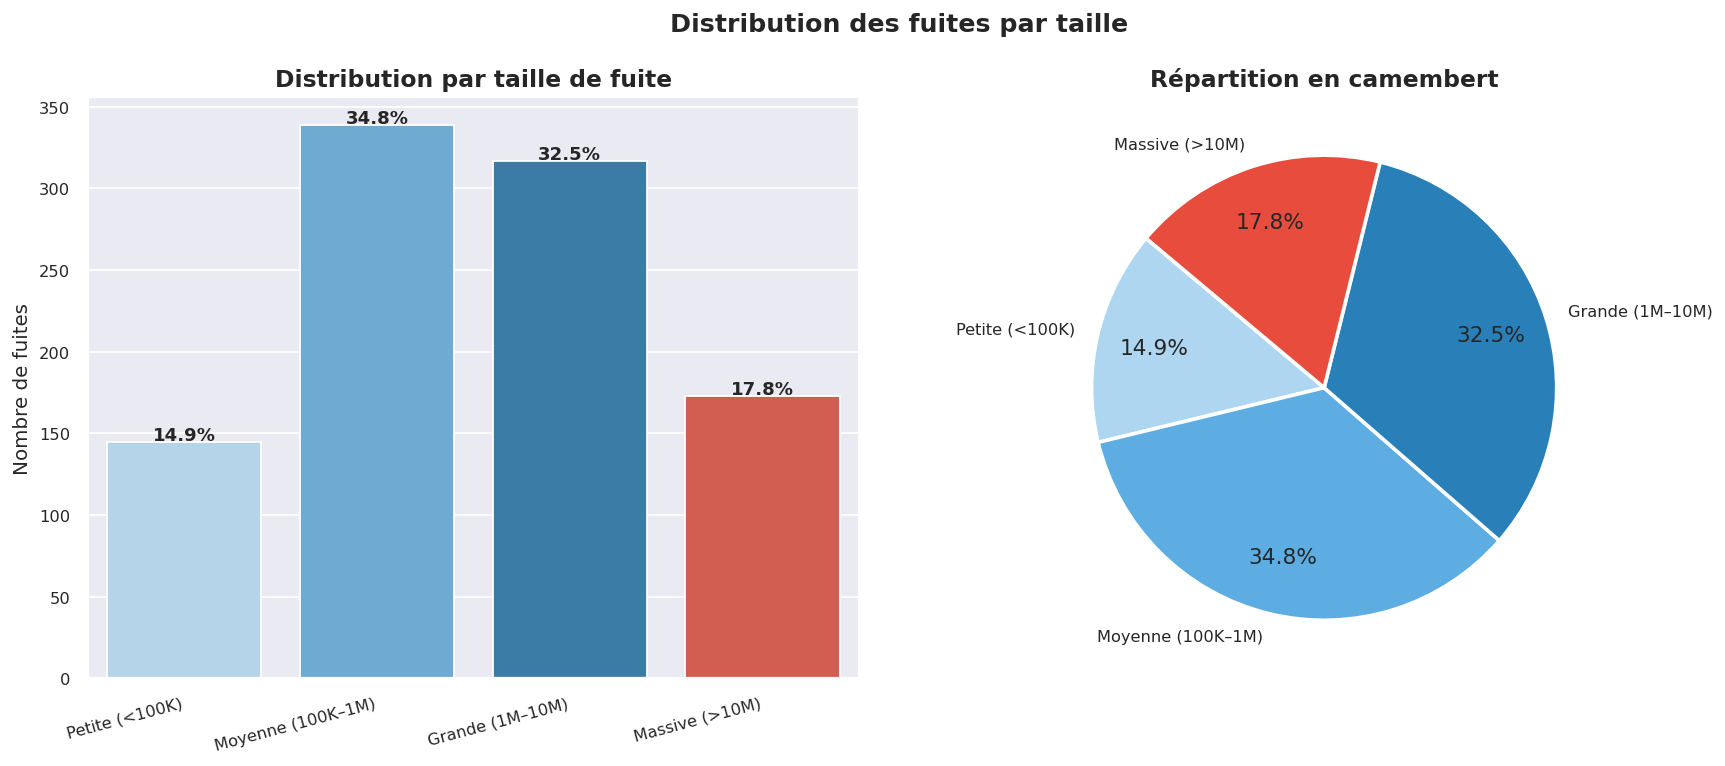

✅ Graphique sauvegardé : 05_distribution_tailles.png


In [8]:
size_order = ['Petite (<100K)', 'Moyenne (100K–1M)', 'Grande (1M–10M)', 'Massive (>10M)']
size_counts = df['BreachSize'].value_counts().reindex(size_order).fillna(0).reset_index()
size_counts.columns = ['BreachSize', 'Count']
size_counts['Pct'] = (size_counts['Count'] / size_counts['Count'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Barplot
palette_size = ['#aed6f1', '#5dade2', '#2980b9', PALETTE2]
sns.barplot(data=size_counts, x='BreachSize', y='Count',
            palette=palette_size, ax=axes[0])
axes[0].set_title('Distribution par taille de fuite')
axes[0].set_xlabel('')
axes[0].set_ylabel('Nombre de fuites')
for bar, pct in zip(axes[0].patches, size_counts['Pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{pct}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_xticklabels(size_counts['BreachSize'], rotation=15, ha='right')

# Pie chart
axes[1].pie(size_counts['Count'], labels=size_counts['BreachSize'],
            colors=palette_size, autopct='%1.1f%%',
            startangle=140, pctdistance=0.75,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Répartition en camembert')

plt.suptitle('Distribution des fuites par taille', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/05_distribution_tailles.png', bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 05_distribution_tailles.png')

---
## 🔥 8. Top 10 des fuites les plus graves
### Q6 — Classement par SeverityScore

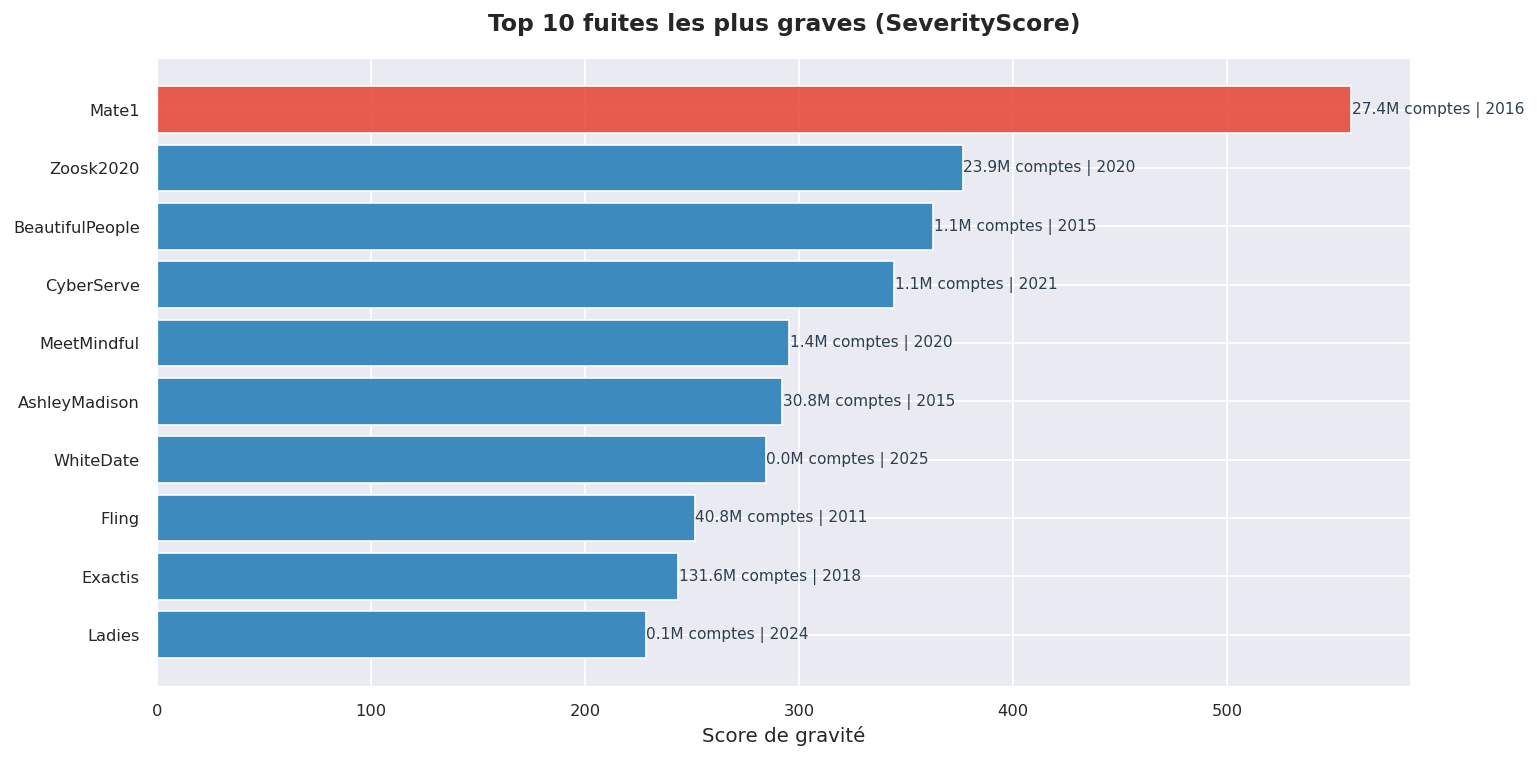

✅ Graphique sauvegardé : 06_top10_severity.png


In [9]:
top10 = df.nlargest(10, 'SeverityScore')[['Name', 'Year', 'SeverityScore', 'PwnCount', 'Sector']].copy()
top10['PwnCount_M'] = (top10['PwnCount'] / 1_000_000).round(1)
top10 = top10.sort_values('SeverityScore')

fig, ax = plt.subplots(figsize=(12, 6))

colors_top = [PALETTE2 if s == top10['SeverityScore'].max() else PALETTE3
              for s in top10['SeverityScore']]

bars = ax.barh(top10['Name'], top10['SeverityScore'],
               color=colors_top, edgecolor='white', alpha=0.9)

for bar, (_, row) in zip(bars, top10.iterrows()):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f"{row['PwnCount_M']}M comptes | {int(row['Year'])}",
            va='center', fontsize=8.5, color='#2c3e50')

ax.set_title('Top 10 fuites les plus graves (SeverityScore)', pad=15)
ax.set_xlabel('Score de gravité')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../visuals/06_top10_severity.png', bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 06_top10_severity.png')

---
## ✅ 9. Fuites vérifiées vs non vérifiées
### Q7 — Répartition IsVerified

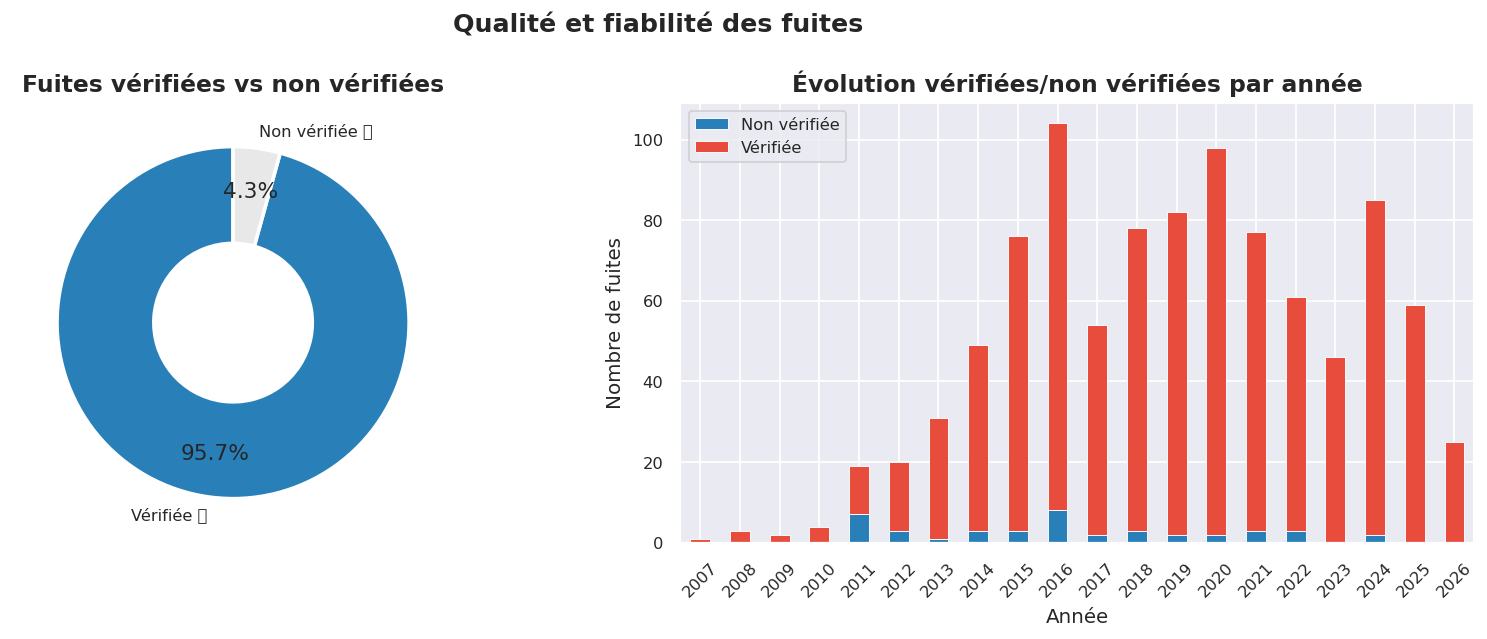

✅ Graphique sauvegardé : 07_verified_analysis.png


In [10]:
verified = df['IsVerified'].value_counts().reset_index()
verified.columns = ['IsVerified', 'Count']
verified['Label'] = verified['IsVerified'].map({True: 'Vérifiée ✅', False: 'Non vérifiée ❌'})
verified['Pct']   = (verified['Count'] / verified['Count'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Donut
wedges, texts, autotexts = axes[0].pie(
    verified['Count'],
    labels=verified['Label'],
    colors=[PALETTE3, '#e8e8e8'],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
axes[0].set_title('Fuites vérifiées vs non vérifiées')

# Évolution vérifiées/non vérifiées dans le temps
trend = df.groupby(['Year', 'IsVerified']).size().unstack(fill_value=0)
trend.columns = ['Non vérifiée', 'Vérifiée']
trend = trend[trend.index >= 2007]
trend.plot(kind='bar', stacked=True, ax=axes[1],
           color=[PALETTE3, PALETTE2], edgecolor='white', linewidth=0.5)
axes[1].set_title('Évolution vérifiées/non vérifiées par année')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Nombre de fuites')
axes[1].legend(loc='upper left', fontsize=9)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Qualité et fiabilité des fuites', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/07_verified_analysis.png', bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 07_verified_analysis.png')

---
## 🔗 10. Corrélation taille vs gravité
### Q8 — Scatter plot PwnCount vs SeverityScore

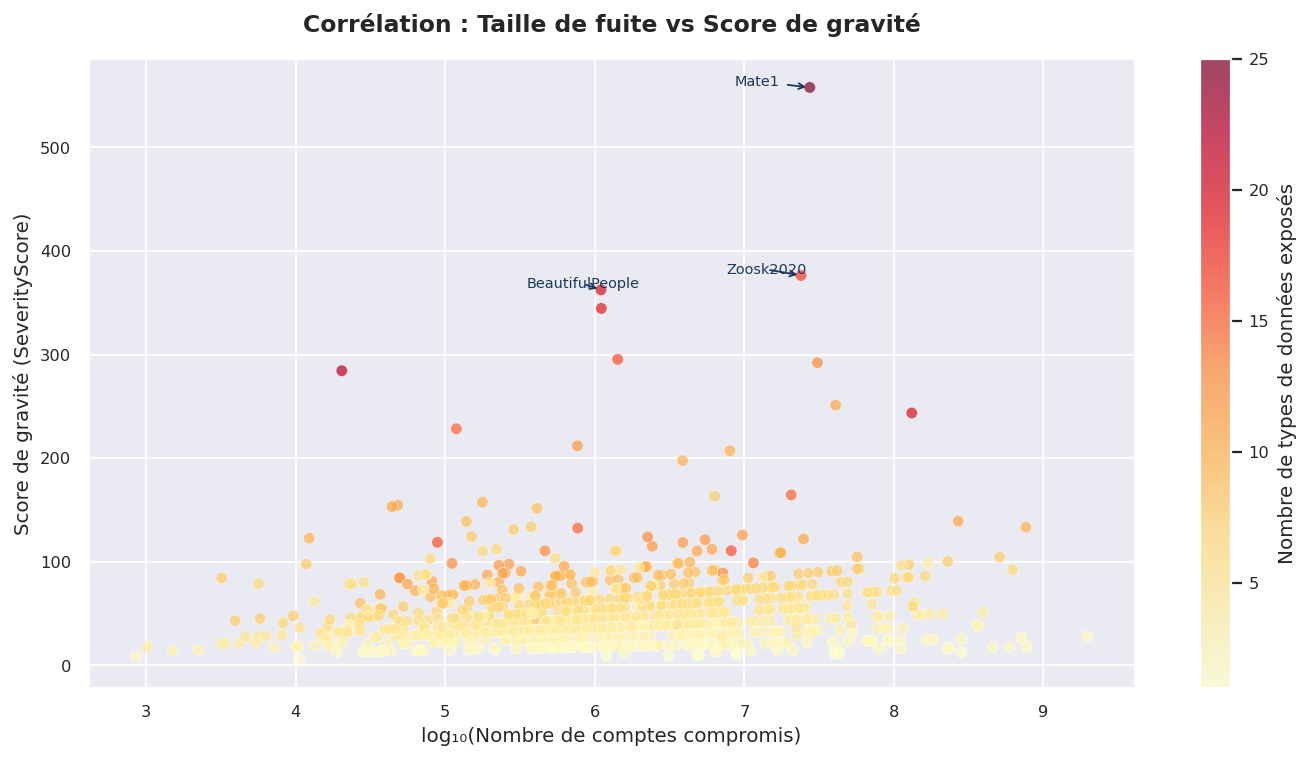

🔗 Coefficient de corrélation (Pearson) : 0.151
✅ Graphique sauvegardé : 08_correlation_taille_gravite.png


In [11]:
df_scatter = df[df['PwnCount'] > 0].copy()
df_scatter['LogPwnCount'] = np.log10(df_scatter['PwnCount'])

fig, ax = plt.subplots(figsize=(11, 6))

scatter = ax.scatter(
    df_scatter['LogPwnCount'],
    df_scatter['SeverityScore'],
    c=df_scatter['NbDataTypes'],
    cmap='YlOrRd',
    alpha=0.7,
    s=40,
    edgecolors='white',
    linewidths=0.3
)

plt.colorbar(scatter, ax=ax, label='Nombre de types de données exposés')

# Annoter les outliers
top3 = df_scatter.nlargest(3, 'SeverityScore')
for _, row in top3.iterrows():
    ax.annotate(row['Name'],
                xy=(row['LogPwnCount'], row['SeverityScore']),
                xytext=(row['LogPwnCount'] - 0.5, row['SeverityScore'] + 2),
                fontsize=8, color=PALETTE,
                arrowprops=dict(arrowstyle='->', color=PALETTE, lw=1))

ax.set_title('Corrélation : Taille de fuite vs Score de gravité', pad=15)
ax.set_xlabel('log₁₀(Nombre de comptes compromis)')
ax.set_ylabel('Score de gravité (SeverityScore)')
plt.tight_layout()
plt.savefig('../visuals/08_correlation_taille_gravite.png', bbox_inches='tight')
plt.show()

# Coefficient de corrélation
corr = df_scatter['LogPwnCount'].corr(df_scatter['SeverityScore'])
print(f'🔗 Coefficient de corrélation (Pearson) : {corr:.3f}')
print('✅ Graphique sauvegardé : 08_correlation_taille_gravite.png')

---
## 📋 11. Tableau récapitulatif — Statistiques par secteur

In [12]:
sector_summary = df.groupby('Sector').agg(
    NbFuites      = ('Name', 'count'),
    TotalComptes  = ('PwnCount', 'sum'),
    MoyenneComptes= ('PwnCount', 'mean'),
    SeverityMoy   = ('SeverityScore', 'mean'),
    PctVerifiees  = ('IsVerified', 'mean')
).reset_index()

sector_summary['TotalComptes_M'] = (sector_summary['TotalComptes'] / 1e6).round(1)
sector_summary['MoyenneComptes'] = sector_summary['MoyenneComptes'].round(0).astype(int)
sector_summary['SeverityMoy']    = sector_summary['SeverityMoy'].round(2)
sector_summary['PctVerifiees']   = (sector_summary['PctVerifiees'] * 100).round(1).astype(str) + '%'
sector_summary = sector_summary.sort_values('TotalComptes_M', ascending=False)

display_cols = ['Sector', 'NbFuites', 'TotalComptes_M', 'SeverityMoy', 'PctVerifiees']
display_cols = [c for c in display_cols if c in sector_summary.columns]

print('📊 Résumé statistique par secteur :')
print(sector_summary[display_cols].to_string(index=False))

📊 Résumé statistique par secteur :
                 Sector  NbFuites  TotalComptes_M  SeverityMoy PctVerifiees
        Autre / Inconnu       877         14950.7        52.01        95.3%
 Tech & Réseaux sociaux        13          1688.9        49.07       100.0%
        Santé & Médical         5           394.3        78.76       100.0%
                 Gaming        34           266.2        38.29       100.0%
    E-commerce & Retail        12           113.0        61.99       100.0%
               Télécoms         8            40.9        50.40        87.5%
Médias & Divertissement        15            35.8        50.60       100.0%
    Voyage & Hôtellerie         4            18.4        56.57       100.0%
              Éducation         3            14.7        74.82       100.0%
       Finance & Crypto         3             0.9        48.93       100.0%


---
## 🗂️ 12. Récapitulatif des fichiers générés

In [13]:
import os
visuals = sorted(os.listdir('../visuals/'))
print('🖼️  Visuels générés dans ../visuals/ :')
for v in visuals:
    size = os.path.getsize(f'../visuals/{v}') / 1024
    print(f'   ✅ {v:45s} ({size:.1f} KB)')

🖼️  Visuels générés dans ../visuals/ :
   ✅ 01_fuites_par_annee.png                       (65.3 KB)
   ✅ 02_comptes_par_annee.png                      (49.3 KB)
   ✅ 03_fuites_par_secteur.png                     (95.6 KB)
   ✅ 04_types_donnees_exposes.png                  (80.9 KB)
   ✅ 05_distribution_tailles.png                   (103.0 KB)
   ✅ 06_top10_severity.png                         (78.1 KB)
   ✅ 07_verified_analysis.png                      (65.3 KB)
   ✅ 08_correlation_taille_gravite.png             (151.0 KB)


---

## ✅ Résumé du Notebook 03

| Question analytique | Graphique | Statut |
|---|---|---|
| Évolution fuites par année | Bar + line chart | ✅ |
| Comptes compromis par année | Bar chart annoté | ✅ |
| Secteurs les plus touchés | Double barplot | ✅ |
| Types de données exposées | Horizontal bar | ✅ |
| Distribution tailles | Bar + pie chart | ✅ |
| Top 10 fuites graves | Horizontal bar | ✅ |
| Vérifiées vs non vérifiées | Donut + stacked bar | ✅ |
| Corrélation taille / gravité | Scatter plot | ✅ |

➡️ **Prochaine étape** : `04_visualizations.ipynb` — Graphiques publication-ready pour GitHub & Gamma